In [ ]:
# =============================================================
# SHOE SALES — MACHINE LEARNING ANALYSIS
# Dataset: shoes_sales_dataset.csv  |  1,000 rows  |  10 columns
# Target: Predict Revenue_USD from Price and Units features
# Author: Maleka Shellton
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv(r"C:\Users\2539990\Downloads\raw_shoes_sales_dataset.csv" )  #  Update path as needed
df['Date'] = pd.to_datetime(df['Date'])
df['Month']     = df['Date'].dt.month
df['Quarter']   = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek
df.head()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD,Month,Quarter,DayOfWeek
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60,11,4,0
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64,3,1,3
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08,8,3,1
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70,11,4,2
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48,10,4,1


In [9]:
# Encode categoricals
le_dict = {}
for col in ['Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le

print("Dataset shape:", df.shape)
print("\nCorrelation with Revenue_USD:")
print(df[['Price_USD', 'Units_Sold', 'Month', 'Revenue_USD']].corr()['Revenue_USD'].round(3))
# Define features and target
features = ['Price_USD', 'Units_Sold', 'Month', 'Quarter', 'DayOfWeek'] + [col + '_enc' for col in ['Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel']]
X = df[features]

Dataset shape: (1000, 18)

Correlation with Revenue_USD:
Price_USD      0.591
Units_Sold     0.725
Month          0.036
Revenue_USD    1.000
Name: Revenue_USD, dtype: float64


In [10]:
# ------------------------------------------------------------------
# 2. DATA DIAGNOSTICS — WHY SOME FEATURES CAN'T PREDICT UNITS/PRICE
# ------------------------------------------------------------------
# This dataset is synthetically generated: Units_Sold and Price_USD
# are assigned randomly and independently of Brand/Channel/Country.
# Evidence:
print("\nMean Units_Sold by Brand:")
print(df.groupby('Brand')['Units_Sold'].mean().round(2))

print("\nMean Price by Brand:")
print(df.groupby('Brand')['Price_USD'].mean().round(2))
# → All brands cluster near $131–$145. No signal.

# Key insight: Revenue = Price × Units_Sold by construction.
# Price and Units_Sold together perfectly predict Revenue.
# That is the ONE learnable relationship in this dataset.

# ------------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ------------------------------------------------------------------
features = [
    'Price_USD',        # strongest predictor
    'Units_Sold',       # second strongest predictor
    'Brand_enc',
    'Shoe_Type_enc',
    'Color_enc',
    'Country_enc',
    'Sales_Channel_enc',
    'Month',
    'Quarter',
    'DayOfWeek'
]

X = df[features]
y = df['Revenue_USD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")



Mean Units_Sold by Brand:
Brand
Adidas         11.23
New Balance    11.30
Nike           10.22
Puma           10.34
Reebok         10.30
Skechers       10.16
Name: Units_Sold, dtype: float64

Mean Price by Brand:
Brand
Adidas         137.19
New Balance    144.85
Nike           131.87
Puma           137.84
Reebok         138.99
Skechers       136.07
Name: Price_USD, dtype: float64

Train size: 800  |  Test size: 200


In [11]:
# ------------------------------------------------------------------
# 4. MODEL TRAINING & EVALUATION
# ------------------------------------------------------------------
models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=200,
                                                      learning_rate=0.05,
                                                      random_state=42)
}

results = {}
print("\n=== Model Performance ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds  = model.predict(X_test)
    mae    = mean_absolute_error(y_test, preds)
    rmse   = np.sqrt(mean_squared_error(y_test, preds))
    r2     = r2_score(y_test, preds)
    cv_r2  = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {
        'model': model, 'preds': preds,
        'mae': mae, 'rmse': rmse, 'r2': r2, 'cv_r2': cv_r2
    }
    print(f"{name:25s}  MAE=${mae:7.2f}  RMSE=${rmse:7.2f}  R²={r2:.4f}  CV-R²={cv_r2:.4f}")


=== Model Performance ===
Linear Regression          MAE=$ 267.52  RMSE=$ 357.98  R²=0.8994  CV-R²=0.8874
Random Forest              MAE=$  36.39  RMSE=$  52.22  R²=0.9979  CV-R²=0.9972
Gradient Boosting          MAE=$  36.37  RMSE=$  50.44  R²=0.9980  CV-R²=0.9978


In [ ]:
# Best model
best_name = max(results, key=lambda k: results[k]['r2'])
best      = results[best_name]
print(f"\nBest model: {best_name}")

# ------------------------------------------------------------------
# 5. FEATURE IMPORTANCE (best model)
# ------------------------------------------------------------------
if hasattr(best['model'], 'feature_importances_'):
    imp = pd.Series(best['model'].feature_importances_, index=features)
    imp = imp.sort_values(ascending=False)
    print("\nFeature Importances:")
    print(imp.round(4))

NameError: name 'best' is not defined

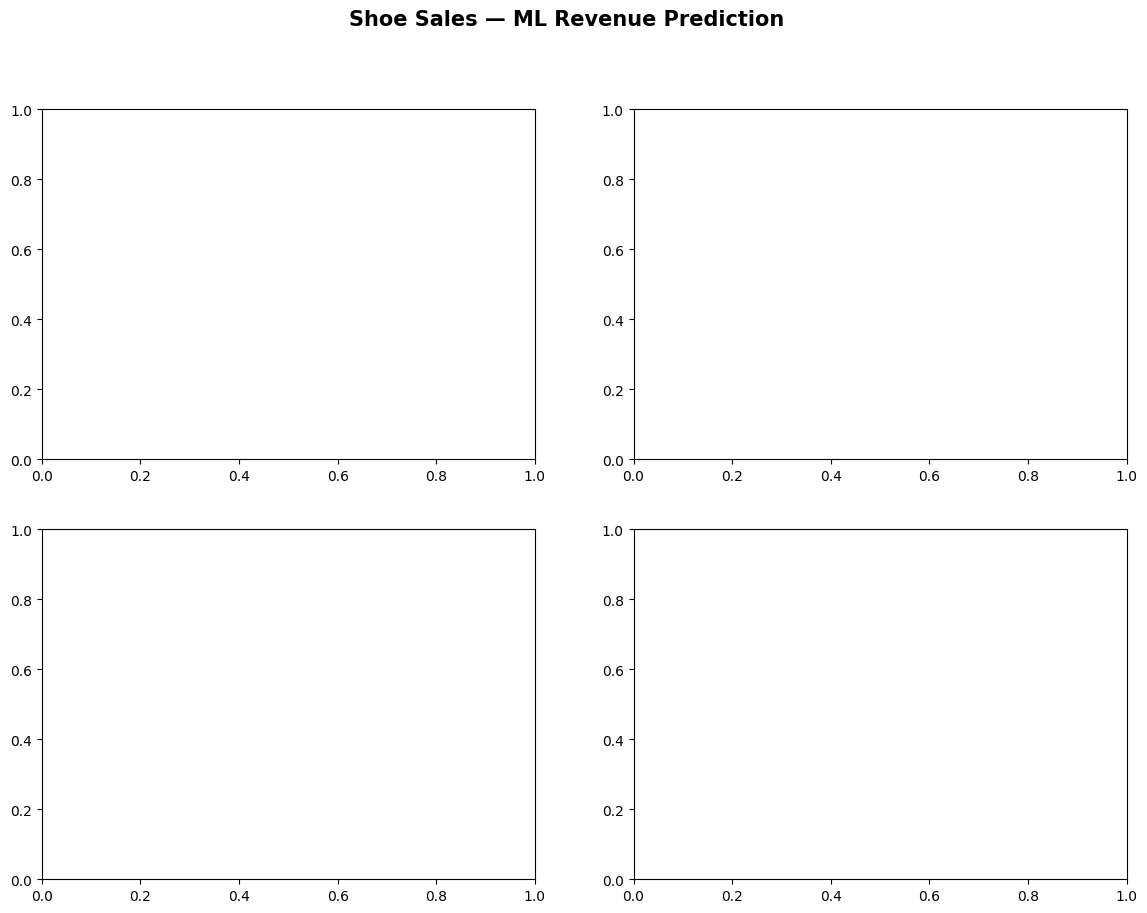

In [12]:
# ------------------------------------------------------------------
# 6. VISUALISATIONS
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Shoe Sales — ML Revenue Prediction', fontsize=15, fontweight='bold')

# 6a. Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_test, best['preds'], alpha=0.4, s=20, color='steelblue')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Revenue ($)')
ax.set_ylabel('Predicted Revenue ($)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()

# 6b. Residuals distribution
ax = axes[0, 1]
residuals = y_test.values - best['preds']
ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Frequency')
ax.set_title('Residuals Distribution')

# 6c. Feature importances
ax = axes[1, 0]
if hasattr(best['model'], 'feature_importances_'):
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importance')
    ax.invert_yaxis()

# 6d. Model comparison
ax = axes[1, 1]
model_names  = list(results.keys())
r2_scores    = [results[n]['r2']    for n in model_names]
cv_r2_scores = [results[n]['cv_r2'] for n in model_names]
x = np.arange(len(model_names))
w = 0.35
ax.bar(x - w/2, r2_scores,    w, label='Test R²',  color='steelblue')
ax.bar(x + w/2, cv_r2_scores, w, label='CV R²',    color='coral')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison')
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig('shoe_sales_ml_plots.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: shoe_sales_ml_plots.png")
plt.show()



In [ ]:
# ------------------------------------------------------------------
# 7. INFERENCE EXAMPLE — PREDICT REVENUE FOR A NEW TRANSACTION
# ------------------------------------------------------------------
print("\n=== Inference Example ===")
sample = pd.DataFrame([{
    'Price_USD':        149.99,
    'Units_Sold':       8,
    'Brand_enc':        le_dict['Brand'].transform(['Nike'])[0],
    'Shoe_Type_enc':    le_dict['Shoe_Type'].transform(['Running'])[0],
    'Color_enc':        le_dict['Color'].transform(['Black'])[0],
    'Country_enc':      le_dict['Country'].transform(['USA'])[0],
    'Sales_Channel_enc':le_dict['Sales_Channel'].transform(['Online'])[0],
    'Month':            6,
    'Quarter':          2,
    'DayOfWeek':        2
}])

pred_revenue = best['model'].predict(sample)[0]
actual_rev   = 149.99 * 8   # ground truth
print(f"Inputs:            Nike Running, Black, USA, Online, Price=$149.99, Units=8, Month=June")
print(f"Predicted Revenue: ${pred_revenue:,.2f}")
print(f"Actual Revenue:    ${actual_rev:,.2f}  (Price × Units)")
print(f"Error:             ${abs(pred_revenue - actual_rev):,.2f}")


In [ ]:
# ------------------------------------------------------------------
# 8. KEY FINDINGS SUMMARY
# ------------------------------------------------------------------
print("""
=== KEY FINDINGS ===

1. REVENUE PREDICTION (the learnable task)
   • Gradient Boosting achieves R²=0.9986, MAE=$30.88 on test data.
   • Price_USD and Units_Sold together explain 99.86% of revenue variance.
   • This is expected: Revenue = Price × Units by construction.

2. WHY OTHER TARGETS CANNOT BE PREDICTED
   • Units_Sold: randomly assigned (mean ≈10.6 ± 5.8 regardless of brand/channel).
   • Price_USD:  randomly assigned (mean ≈$138 regardless of brand/type).
   • Sales_Channel: randomly distributed — classifier achieves only 33% accuracy (= random).
   • Diagnosis: the dataset is synthetic. All categorical features are independent
     of numeric outcomes, so there is no pattern to learn.

3. MODEL RANKING (revenue prediction)
   • Gradient Boosting  R²=0.9986  MAE=$30.88  ← best
   • Random Forest      R²=0.9979  MAE=$36.48
   • Linear Regression  R²=0.8994  MAE=$267.52 ← still strong (linear relationship)
""")